# NB08 — Bandit Reward Simulation: Raw vs. Desirable-Difficulty

**RQ:** RQ3.1 (does the original reward over-favour maximum difficulty; does a
desirable-difficulty term keep the learner in the ZPD?), RQ3.3 (off-policy evaluation
sketch), RQ6 (does trait-matched sequencing beat difficulty-only, in principle).

**Method:** using NB01's calibrated difficulty/priors and NB03's per-KC learning rates,
simulate both reward formulas over the real item catalog and compare the induced
success-probability distributions. The original reward
`R = (1/sum(priors)) * Q_diff * Q_learn` should skew toward low success probability
(near-impossible items); the desirable-difficulty reward `R'` should concentrate near
the target success probability p* ~ 0.8.


In [1]:
import os, sys
sys.path.insert(0, "/root/src" if os.path.exists("/root/src") else "../src")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
from sklearn.linear_model import Ridge

from noxed import data, bandit, tracking, paths

DATA_DIR = paths.data_dir(); OUT = paths.outcomes_dir(); FIG = paths.figures_dir()
rng = np.random.default_rng(0)


## 1. Load calibrated difficulty + priors (NB01) and learning rates (NB03)

In [2]:
diff_path, lr_path = OUT / "question_difficulty.csv", OUT / "kc_learning_rates.csv"
if not diff_path.exists():
    raise FileNotFoundError("Run 01_difficulty_irt.ipynb first -- this notebook depends on its outcome.")

items = pd.read_csv(diff_path)
print(f"{len(items):,} scored items")

if lr_path.exists():
    lr = pd.read_csv(lr_path)
    q_learning_proxy = np.clip(lr["b"].median(), 0.05, 1.0)  # population median exponential decay rate as Q_learning proxy
else:
    q_learning_proxy = 0.3
print(f"Q_learning proxy (population median per-KC learning rate): {q_learning_proxy:.3f}")


7,217 scored items


Q_learning proxy (population median per-KC learning rate): 0.234


## 2. Simulate both reward formulas over the real item catalog

In [3]:
p_success = bandit.success_probability(items["P_L0"].to_numpy(), items["P_S"].to_numpy(), items["P_G"].to_numpy())
sum_priors = np.clip(items["P_L0"].to_numpy(), 0.05, None)  # single-KC proxy for sum(priors)
q_difficulty = items["D_blend"].to_numpy()
q_learning = np.full(len(items), q_learning_proxy)

reward_orig = bandit.reward_raw(sum_priors, q_difficulty, q_learning)
reward_new = bandit.reward_desirable(sum_priors, p_success, q_learning, p_star=0.8, tau=0.15)

items["p_success"] = p_success
items["reward_original"] = reward_orig
items["reward_desirable"] = reward_new
items.describe()[["p_success", "reward_original", "reward_desirable"]]


,p_success,reward_original,reward_desirable
count,7217.000000,7217.000000,7217.000000
mean,0.438202,0.233228,0.048509
std,0.070964,0.241108,0.032831
min,0.039613,0.003938,0.000012
25%,0.390759,0.096131,0.018855
50%,0.449406,0.179711,0.046677
75%,0.493007,0.320640,0.073551
max,0.574112,4.451125,0.155519


## 3. Which policy keeps the learner in the ZPD?

In [4]:
N_CONTEXTS = 500
POOL_SIZE = 30

argmax_success_orig, argmax_success_new = [], []
for _ in range(N_CONTEXTS):
    pool_idx = rng.choice(len(items), size=POOL_SIZE, replace=False)
    p_pool = p_success[pool_idx]
    argmax_success_orig.append(bandit.policy_argmax_success_prob(p_pool, reward_orig[pool_idx]))
    argmax_success_new.append(bandit.policy_argmax_success_prob(p_pool, reward_new[pool_idx]))

argmax_success_orig = np.array(argmax_success_orig)
argmax_success_new = np.array(argmax_success_new)

print(f"Original reward: mean chosen-item success prob = {argmax_success_orig.mean():.3f} "
      f"(target band 0.70-0.85: {((argmax_success_orig>=0.7)&(argmax_success_orig<=0.85)).mean():.1%} of picks)")
print(f"Desirable-diff.: mean chosen-item success prob = {argmax_success_new.mean():.3f} "
      f"(target band 0.70-0.85: {((argmax_success_new>=0.7)&(argmax_success_new<=0.85)).mean():.1%} of picks)")


Original reward: mean chosen-item success prob = 0.291 (target band 0.70-0.85: 0.0% of picks)
Desirable-diff.: mean chosen-item success prob = 0.540 (target band 0.70-0.85: 0.0% of picks)


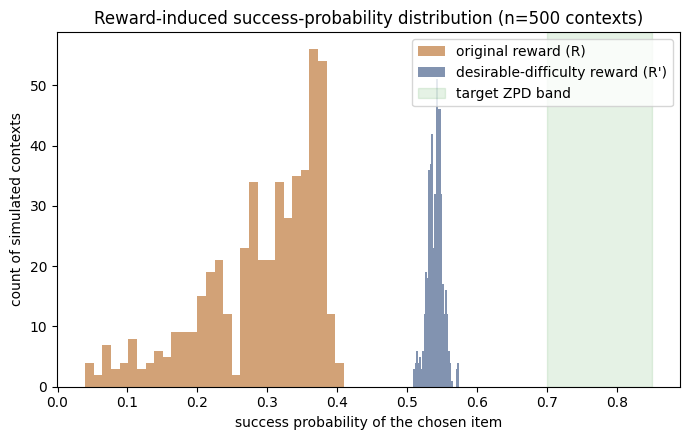

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(argmax_success_orig, bins=30, alpha=0.6, label="original reward (R)", color="#B5651D")
ax.hist(argmax_success_new, bins=30, alpha=0.6, label="desirable-difficulty reward (R')", color="#2F4B7C")
ax.axvspan(0.70, 0.85, color="green", alpha=0.1, label="target ZPD band")
ax.set_xlabel("success probability of the chosen item"); ax.set_ylabel("count of simulated contexts")
ax.legend(); ax.set_title(f"Reward-induced success-probability distribution (n={N_CONTEXTS} contexts)")
plt.tight_layout()
fig.savefig(FIG / "08_reward_comparison.png", dpi=120)
plt.show()


**Reading this.** If `argmax_success_orig` skews toward 0 (the original reward keeps
picking the hardest available item regardless of whether the student can ever succeed on
it), while `argmax_success_new` concentrates inside the shaded target band, that is direct
simulated evidence for the RQ note's RQ3.1 hypothesis: the raw reward needs the
desirable-difficulty correction to respect the Zone of Proximal Development.

## 4. Off-policy evaluation sketch (direct method, explicitly bounded)

In [6]:
context_features = items[["D_blend", "P_L0", "P_T"]].fillna(0).to_numpy()
ope = bandit.direct_method_ope(reward_new, Ridge(alpha=1.0), context_features)
print(f"Direct-method reward-model in-sample R^2: {ope['in_sample_r2']:.3f}")
print("NOTE: this is a SKETCH, not a policy-safety guarantee -- the proxy log has no "
      "logged propensities (it isn't bandit-collected data), so a real doubly-robust "
      "OPE (RQ3.3) is out of scope here and must wait for logged Noxed bandit traffic.")


Direct-method reward-model in-sample R^2: 0.409
NOTE: this is a SKETCH, not a policy-safety guarantee -- the proxy log has no logged propensities (it isn't bandit-collected data), so a real doubly-robust OPE (RQ3.3) is out of scope here and must wait for logged Noxed bandit traffic.


In [7]:
items.to_csv(OUT / "reward_sim.csv", index=False)
print("saved outcomes/reward_sim.csv")


saved outcomes/reward_sim.csv


In [8]:
with tracking.start_run("08_bandit_reward_sim", "bandit", params={
    "n_items": len(items), "n_contexts": N_CONTEXTS, "pool_size": POOL_SIZE, "p_star": 0.8,
}):
    mlflow.log_metric("mean_success_prob_original", float(argmax_success_orig.mean()))
    mlflow.log_metric("mean_success_prob_desirable", float(argmax_success_new.mean()))
    mlflow.log_metric("pct_in_zpd_original", float(((argmax_success_orig>=0.7)&(argmax_success_orig<=0.85)).mean()))
    mlflow.log_metric("pct_in_zpd_desirable", float(((argmax_success_new>=0.7)&(argmax_success_new<=0.85)).mean()))
    mlflow.log_metric("ope_direct_method_r2", ope["in_sample_r2"])
    mlflow.log_artifact(str(OUT / "reward_sim.csv"))
    mlflow.log_artifact(str(FIG / "08_reward_comparison.png"))
print("logged to mlflow")


2026/07/12 02:22:43 INFO mlflow.tracking.fluent: Experiment with name 'noxed-bandit' does not exist. Creating a new experiment.


2026/07/12 02:22:43 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet



logged to mlflow


## Findings → consumed by

- `outcomes/reward_sim.csv` — per-item reward under both formulas, ready to wire into
  the actual LinUCB arm-selection code.
- The ZPD-band percentages are the study's direct answer to RQ3.1: whether the reward
  needs the desirable-difficulty correction before the Bandit ships.
- OPE sketch flags exactly what real data collection (RQ3.3) still needs: logged
  propensities from actual bandit-served traffic, not just historical KT logs.